In [1]:
import numpy as np 
import torch 

from src.spatial_attn_lightning import BinauralAttentionModule
from corpus.swc_mono_test import SWCMonoTestSetH5Dataset
import yaml 

%matplotlib inline 
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


In [2]:
outfig_dest = Path('ARO_2025/')
outfig_dest.mkdir(parents=True, exist_ok=True)

In [3]:
config_path = 'config/binaural_attn/word_task_v10_main_feature_gain_config.yaml'
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

In [4]:
config['audio']['rep_kwargs']['rep_on_gpu'] = False

In [5]:
model = BinauralAttentionModule(config)
coch_gram = model.coch_gram

Using explicit dim specification for demeaning in audio transforms
Using BinauralAuditoryAttentionCNN
v08 True
num_classes={'num_words': 800}
Model performing word task
Using singe gain function per layer
Conv block order: LN -> Conv -> ReLU
fc_attn: True
coch_affine: True
center_crop=True
binaural=True
Binaural cochleagram
using IIR cochleagram


In [6]:
h5_path = "/om/user/imgriff/datasets/human_word_rec_SWC_2024/model_eval_stim.h5"
dataset = SWCMonoTestSetH5Dataset(h5_path=h5_path,
                                eval_distractor_cond='1-talker-english-different',
                                model_sr=44_100,
                                label_type='CV')

In [7]:
cue, target, distractor, word_int, dist_word_int = dataset[0]

(-5512.450000000001, 115761.45, -0.10987069383263588, 0.1303173966705799)

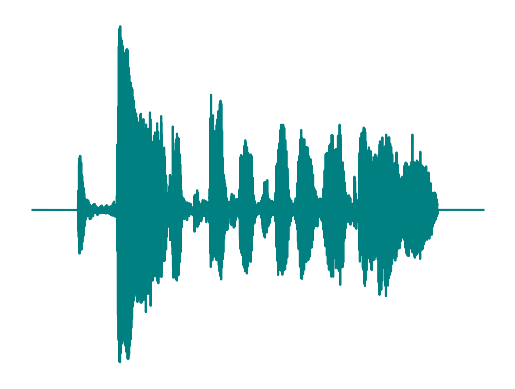

In [8]:
plt.plot(cue, 'teal');
plt.axis('off')

# plt.savefig(outfig_dest/'cue_wav_eg.pdf', transparent=True, bbox_inches='tight')

(-5512.450000000001, 115761.45, -0.11885507255792618, 0.12160165458917618)

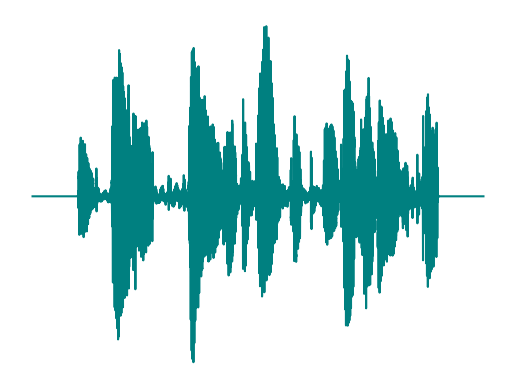

In [9]:
plt.plot(target, 'teal');
plt.axis('off')

# plt.savefig(outfig_dest/'target_wav_eg.pdf', transparent=True, bbox_inches='tight')

(-5512.450000000001, 115761.45, -0.17598120272159576, 0.21949920952320098)

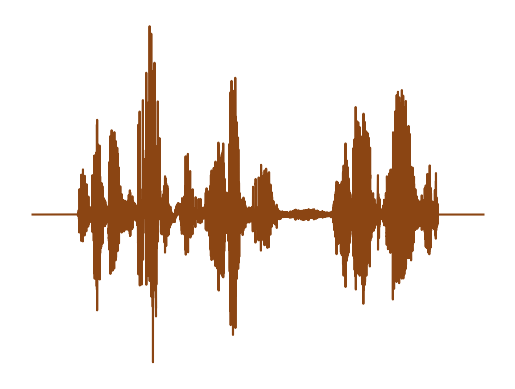

In [10]:
plt.plot(distractor, 'saddlebrown');
plt.axis('off')

# plt.savefig(outfig_dest/'dist_wav_eg.pdf', transparent=True, bbox_inches='tight')

(-5512.450000000001, 115761.45, -0.17598120272159576, 0.21949920952320098)

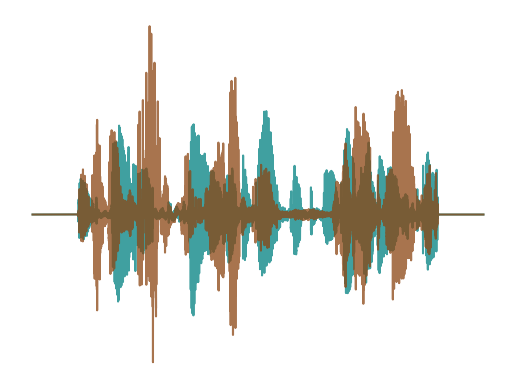

In [11]:
plt.plot(target, 'teal', alpha=0.75);
plt.plot(distractor, 'saddlebrown', alpha=0.75);

plt.axis('off')
# plt.savefig(outfig_dest/'mixture_wav_eg.pdf', transparent=True, bbox_inches='tight')

(-5512.450000000001, 115761.45, -0.10987069383263588, 0.1303173966705799)

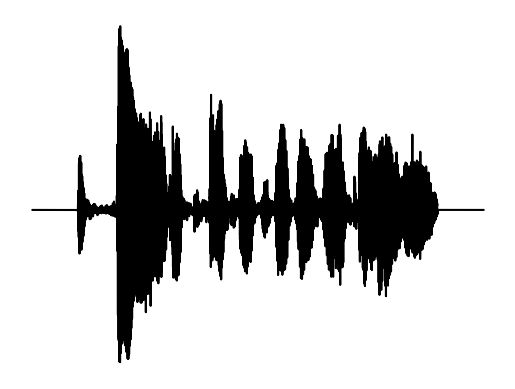

In [12]:
plt.plot(cue, 'k');
plt.axis('off')

# plt.savefig(outfig_dest/'raw_wav_eg.pdf', transparent=True, bbox_inches='tight')

In [13]:
torch.from_numpy(target).repeat(1,2).shape

torch.Size([1, 220500])

In [14]:
target_coch, dist_coch = coch_gram(torch.from_numpy(target).repeat(1,2).reshape(1,2,-1), torch.from_numpy(distractor).repeat(1,2).reshape(1,2,-1))
cue_coch, _ = coch_gram(torch.from_numpy(cue).repeat(1,2).reshape(1,2,-1), None)

In [15]:
target_coch.shape

torch.Size([2, 40, 20000])

In [16]:
### Set coch fig size

coch_size = (3,2)

([<matplotlib.axis.YTick at 0x14c87ab2f5e0>,
 [Text(0, 1, '20 kHz'), Text(0, 39, '20 Hz')])

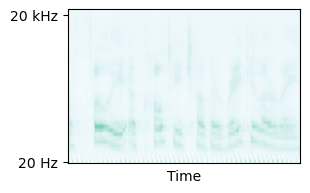

In [17]:
plt.figure(figsize=coch_size)
plt.imshow(cue_coch[1].numpy(), aspect='auto', origin='upper', cmap='BuGn');
# plt.ylabel('Frequency')
plt.xlabel('Time')
plt.xticks([])
plt.yticks([1,39], ['20 kHz', '20 Hz'])
# plt.savefig(outfig_dest/'cue_coch.pdf', transparent=True, bbox_inches='tight')

([<matplotlib.axis.YTick at 0x14c87a8312e0>,
 [Text(0, 1, '20 kHz'), Text(0, 39, '20 Hz')])

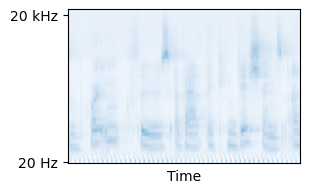

In [18]:
plt.figure(figsize=coch_size)
plt.imshow(target_coch[1].numpy(), aspect='auto', origin='upper', cmap='Blues');
# plt.ylabel('Frequency')
plt.xlabel('Time')
plt.xticks([])
plt.yticks([1,39], ['20 kHz', '20 Hz'])
# plt.savefig(outfig_dest/'target_coch.pdf', transparent=True, bbox_inches='tight')

([<matplotlib.axis.YTick at 0x14c87a7f71c0>,
 [Text(0, 1, '20 kHz'), Text(0, 39, '20 Hz')])

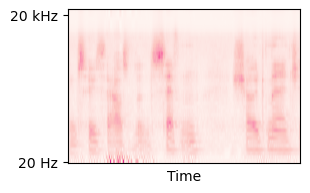

In [19]:
plt.figure(figsize=coch_size)
plt.imshow(dist_coch[1].numpy(), aspect='auto', origin='upper', cmap='RdPu');
# plt.ylabel('Frequency')
plt.xlabel('Time')
plt.xticks([])
plt.yticks([1,39], ['20 kHz', '20 Hz'])
# plt.savefig(outfig_dest/'dist_coch.pdf', transparent=True, bbox_inches='tight')

([<matplotlib.axis.YTick at 0x14c87a7b2fd0>,
 [Text(0, 1, '20 kHz'), Text(0, 39, '20 Hz')])

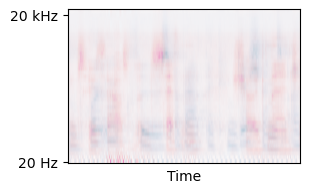

In [20]:
### Given mixture of two spectrograms, color pixels based on whether the max value is from the first or second spectrogrma 

plt.figure(figsize=coch_size)
plt.imshow(target_coch[1].numpy(), aspect='auto', origin='upper', cmap='Blues');
plt.imshow(dist_coch[1].numpy(), aspect='auto', origin='upper', cmap='RdPu', alpha=0.5);
# plt.ylabel('Frequency')
plt.xlabel('Time')
plt.xticks([])
plt.yticks([1,39], ['20 kHz', '20 Hz'])
# plt.savefig(outfig_dest/'mix_coch.png', transparent=True, dpi=500, bbox_inches='tight')

([<matplotlib.axis.YTick at 0x14c879481970>,
 [Text(0, 1, '20 kHz'), Text(0, 39, '20 Hz')])

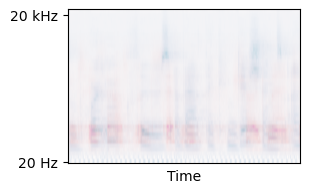

In [24]:
### Given mixture of two spectrograms, color pixels based on whether the max value is from the first or second spectrogrma 

gain_vector = np.ones((40)) 

gain_vector[:30] = np.hanning(60)[:30] * 0.5
gain_vector[35:] = np.hanning(10)[5:] * 0.5

gain_vector = gain_vector[:, None]

plt.figure(figsize=coch_size)
plt.imshow(target_coch[1].numpy(), aspect='auto', origin='upper', cmap='Blues');
plt.imshow(dist_coch[1].numpy() * gain_vector, aspect='auto', origin='upper', cmap='RdPu', alpha=0.5);
# plt.ylabel('Frequency')
plt.xlabel('Time')
plt.xticks([])
plt.yticks([1,39], ['20 kHz', '20 Hz'])
# plt.savefig(outfig_dest/'attended_coch.pdf', transparent=True, bbox_inches='tight')

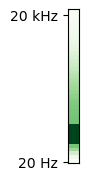

In [36]:
plt.figure(figsize=coch_size)
to_plot = np.repeat(gain_vector, 3, axis=1)

plt.imshow(to_plot, origin='upper', cmap='Greens', vmax=1, interpolation='None');
plt.xticks([])
plt.yticks([1,39], ['20 kHz', '20 Hz'])
plt.savefig(outfig_dest/'gains_eg.pdf', transparent=True, bbox_inches='tight')

([<matplotlib.axis.YTick at 0x14ddea80a310>,
 [Text(0, 1, '20 kHz'), Text(0, 39, '20 Hz')])

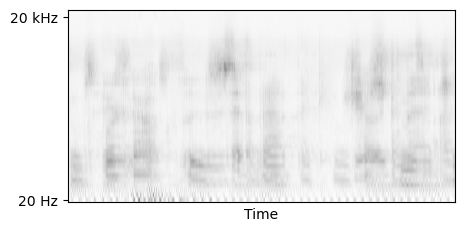

In [ ]:
mix_coch = target_coch[0] + dist_coch[0]
plt.figure(figsize=(5,2.5))
plt.imshow(mix_coch.numpy(), aspect='auto', origin='upper', cmap='Greys');
# plt.ylabel('Frequency')
plt.xlabel('Time')
plt.xticks([])
plt.yticks([1,39], ['20 kHz', '20 Hz'])